## Objective 1: Data Cleaning With EDA


In [1]:
import numpy as np
import seaborn as sns 

from sklearn.tree import plot_tree
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans, AgglomerativeClustering


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingClassifier, BaggingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score



In [5]:
df= pd.read_csv("Autocomp - Companies list (CA-1).csv")
df.head()

,Name of the company,Location,Listed,Products,Revenue,EBITDA (IN MILLIONS),Website
0,3DS LIGHTING SOLUTIONS PVT LTD,NaN,NaN,NaN,NaN,NaN,NaN
1,99 AUTO FLASH,NaN,NaN,NaN,NaN,NaN,NaN
2,A.R SPARES PVT LTD,NaN,NaN,NaN,NaN,NaN,NaN
3,AARCO INDUSTRIES PVT LTD,JALANDHAR,NO,"Our range comprises Axle Spindle, Steel Spindl...",NaN,NaN,https://aarcoindustries.com/
4,ABATEK (ASIA) PUBLIC COMPANY LIMITED,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df= pd.read_csv("Autocomp - Companies list (CA-1).csv")

df = df.drop_duplicates()
df = df.dropna()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.reset_index(drop=True)
print(df.shape)
print(df.info())
print(df.describe())
print(df.isna().sum())
print(df.nunique())
df.head(10)

(236, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Name of the company   236 non-null    object
 1   Location              236 non-null    object
 2   Listed                236 non-null    object
 3   Products              236 non-null    object
 4   Revenue               236 non-null    object
 5   EBITDA (IN MILLIONS)  236 non-null    object
 6   Website               236 non-null    object
dtypes: object(7)
memory usage: 13.0+ KB
None
                         Name of the company Location Listed  \
count                                    236      236    236   
unique                                   236       38      2   
top     ABILITIES INDIA PISTONS & RINGS LTD.  HARYANA     NO   
freq                                       1       34    209   

                Products        Revenue  EBITDA (IN MILLIONS)  \
count

,Name of the company,Location,Listed,Products,Revenue,EBITDA (IN MILLIONS),Website
0,ABILITIES INDIA PISTONS & RINGS LTD.,DELHI,NO,PISTON AND RINGS,1103.43 (2023),140.41 (2023),http://aippistons.com/
1,ACCOLADE ELECTRONICS PRIVATE LIMITED,PUNE,NO,"LED (light-emitting diode) emergency light, in...",1275.45 (2023),146.97 (2023),http://accoladeelectronics.com/
2,ADITYA AUTOS,BANGALORE,NO,"window regulators, door latches, tailgate latc...",6384.40 (2024),357.20 (2024),http://www.adityaauto.com/
3,ADVIK HI-TECH PRIVATE LIMITED,PUNE,NO,"lifter tensioner, oil pumps, fuel cocks – man...",6771.60 (2024),1724.9 (2024),http://www.advik.co.in/
4,ALF ENGINEERING PVT. LTD.,MUMBAI,NO,"chassis, hydroformed parts, suspension assembl...",13920.06 (2023),1526.56 (2023),http://www.alfengineering.com/
5,ALICON CASTALLOY LTD.,PUNE,YES,"cylinder heads, support brackets, intake manif...",13923.14 (2024),1736.42 (2024),http://alicongroup.co.in/
6,ALKRAFT THERMOTECHNOLOGIES PRIVATE LIMITED,JAMSHEDPUR,NO,"radiators, charge air coolers, modular systems...",983.57 (2022),47.96 (2022),http://www.alkraft.com/
7,ALLENA AUTO INDUSTRIES PVT LTD,"MOHALI, PUNJAB",NO,"water pumps, oil filter, pump assemblies, wate...",2755 (2023),167.26 (2023),http://www.allenaauto.com/
8,ALLIED TRANSMISSION AND GEARS PRIVATE LIMITED,SONEPAT,NO,mercedes transmission parts include automatic ...,147.92 (2023),23.09 (2023),http://www.alliedtransmission.in/
9,ALMIGHTY AUTO ANCILLARY PVT. LTD.,MUMBAI,NO,"wiper motors, wiper linkages, wiper arms, wipe...",437.06 (2021),28.19 (2021),http://www.almity.com/


## Objective 2: Dimensionality Reduction using PCA & Pairplot


        PC1       PC2
0 -2.628323 -0.672789
1 -2.539745 -1.279336
2 -1.866283  1.650854
3 -1.972933  0.341492
4 -2.284154 -1.172036


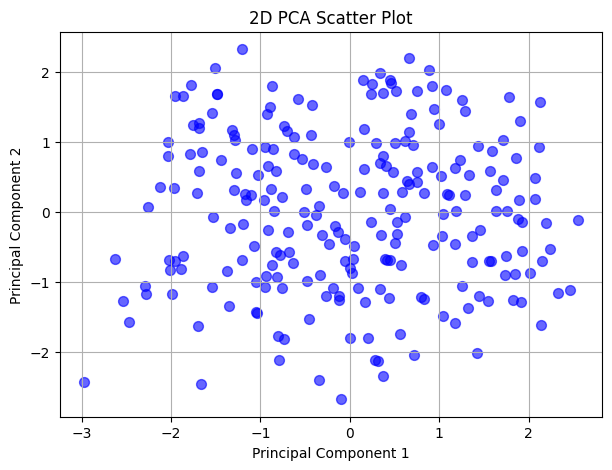

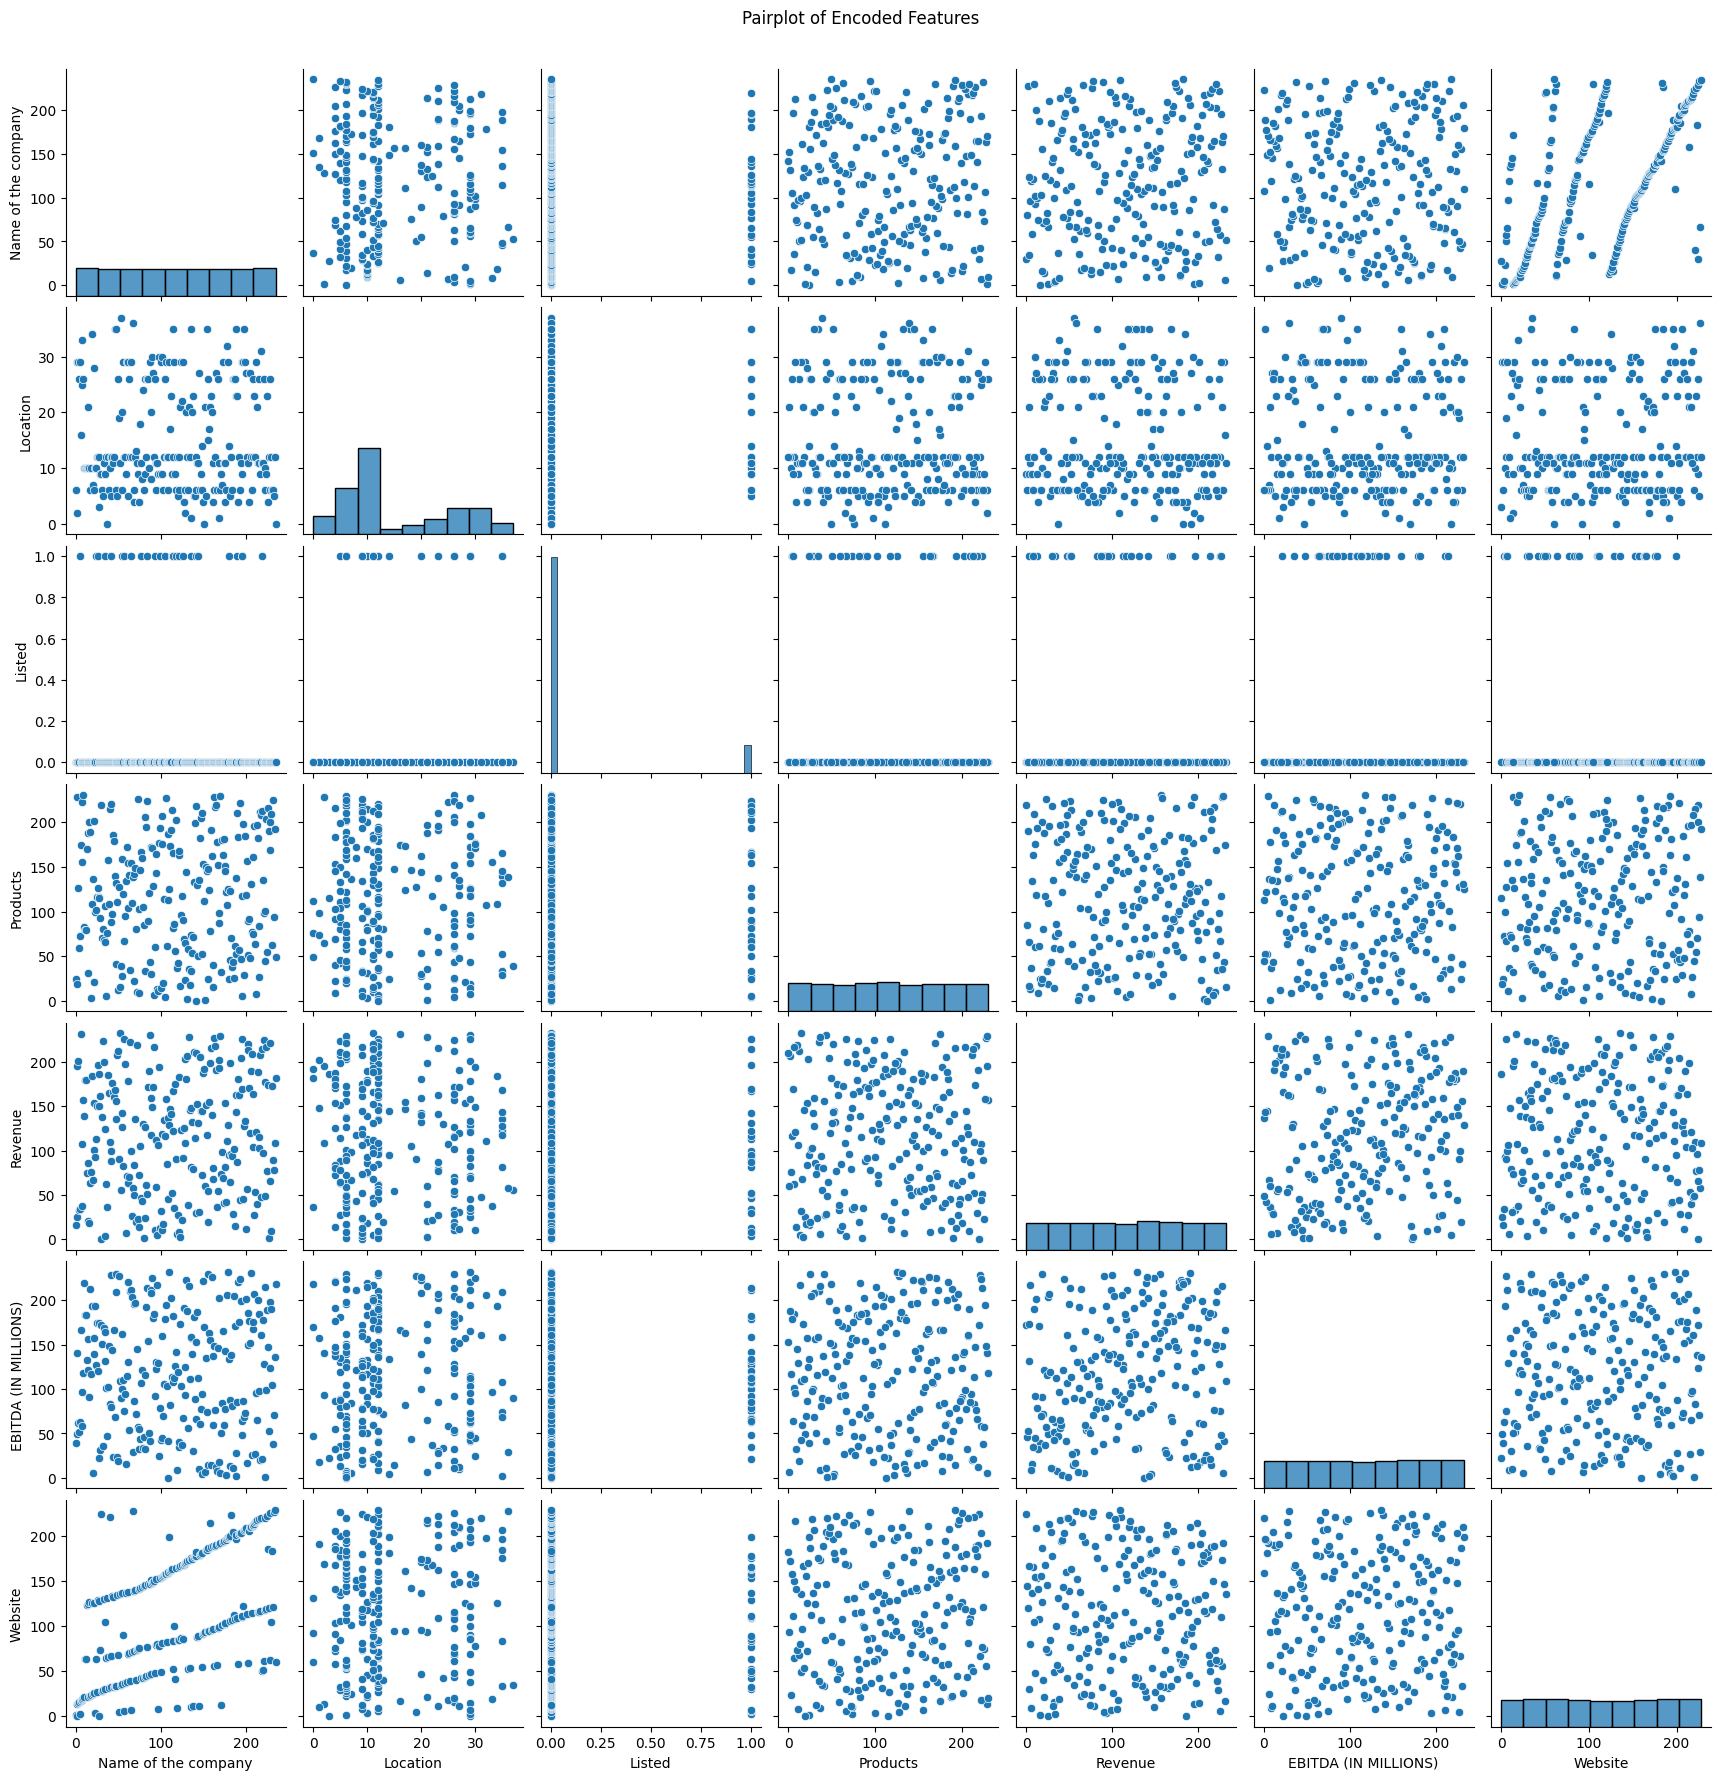

In [67]:
df2 = df.copy()

for col in df2.columns:
    df2[col] = df2[col].astype(str).str.strip()

# ------------------------------
# 2. LABEL ENCODING (Because no numeric columns exist)
# ------------------------------
le = LabelEncoder()
df_encoded = df2.copy()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ------------------------------
# 3. SCALING
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ------------------------------
# 5. RESULT DATAFRAME
# ------------------------------
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
print(pca_df.head())

# -------------------- 4. Scatter Plot of PCA --------------------
plt.figure(figsize=(7,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=50, c='blue', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Scatter Plot')
plt.grid(True)
plt.show()

# -------------------- 5. Pairplot of Encoded Features --------------------
sns.pairplot(df_encoded)
plt.suptitle("Pairplot of Encoded Features", y=1.02)
plt.show()


## Objective 3: Clustering using KMeans, Agglomerative Clustering with Scatter Maps





In [1]:
# -------------------- Clean & Prepare Data --------------------
df['Revenue'] = (
    df['Revenue'].astype(str)
    .str.extract(r'([\d,.]+)')
    .replace(',', '', regex=True)
    .astype(float)
)

df['EBITDA (IN MILLIONS)'] = (
    df['EBITDA (IN MILLIONS)'].astype(str)
    .str.extract(r'([\d,.]+)')
    .replace(',', '', regex=True)
    .astype(float)
)

X = df[['Revenue', 'EBITDA (IN MILLIONS)']].values

# -------------------- Standardize --------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------- KMeans --------------------
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# KMeans Metrics
print("\n===== KMEANS METRICS =====")
print("Silhouette Score:", silhouette_score(X_scaled, klabels))
print("Davies-Bouldin Score:", davies_bouldin_score(X_scaled, klabels))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_scaled, klabels))
print("Inertia (WCSS):", kmeans.inertia_)
print("Cluster Counts:", np.bincount(klabels))


# -------------------- Agglomerative Clustering --------------------
# Choose optimal number of clusters (e.g., 3) and linkage
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')  # try 'complete' or 'average' too
labels = agg.fit_predict(X_scaled)

# -------------------- Scatter Plot --------------------
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='plasma', s=50)
plt.title('Agglomerative Clustering')
plt.xlabel('Revenue (scaled)')
plt.ylabel('EBITDA (scaled)')
plt.show()

# -------------------- Metrics --------------------
print("===== Agglomerative Clustering Metrics =====")
print("Silhouette Score:", silhouette_score(X_scaled, labels))
print("Davies-Bouldin Score:", davies_bouldin_score(X_scaled, labels))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_scaled, labels))
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Counts:", dict(zip(unique, counts)))


NameError: name 'df' is not defined

## Objective 4: Classification using SVM & Decision Trees with Confusion Matrix


Best SVC Parameters: {'C': 50, 'gamma': 1, 'kernel': 'rbf'}
Confusion matrix SVC
[[28  1  0]
 [ 1 22  2]
 [ 0  1 16]]

===== Scores SVC =====
Accuracy: 0.9295774647887324
Precision (macro): 0.9236909323116219
Recall (macro): 0.9288979039891819
F1-score (macro): 0.9259207131128314


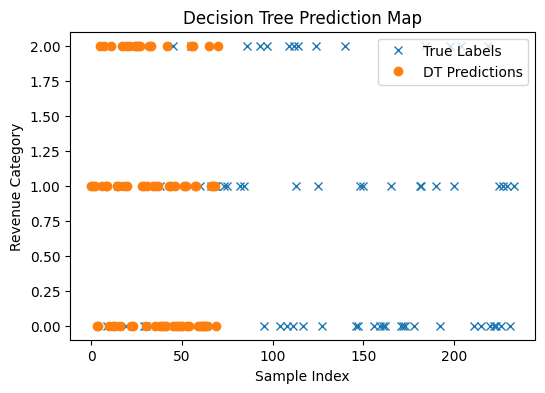

Confusion matrix Decision Tree
[[28  1  0]
 [ 0 25  0]
 [ 0  0 17]]

===== Scores Decision Tree =====
Accuracy: 0.9859154929577465
Precision (macro): 0.9871794871794872
Recall (macro): 0.9885057471264368
F1-score (macro): 0.9876160990712074

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.96      1.00      0.98        25
           2       1.00      1.00      1.00        17

    accuracy                           0.99        71
   macro avg       0.99      0.99      0.99        71
weighted avg       0.99      0.99      0.99        71



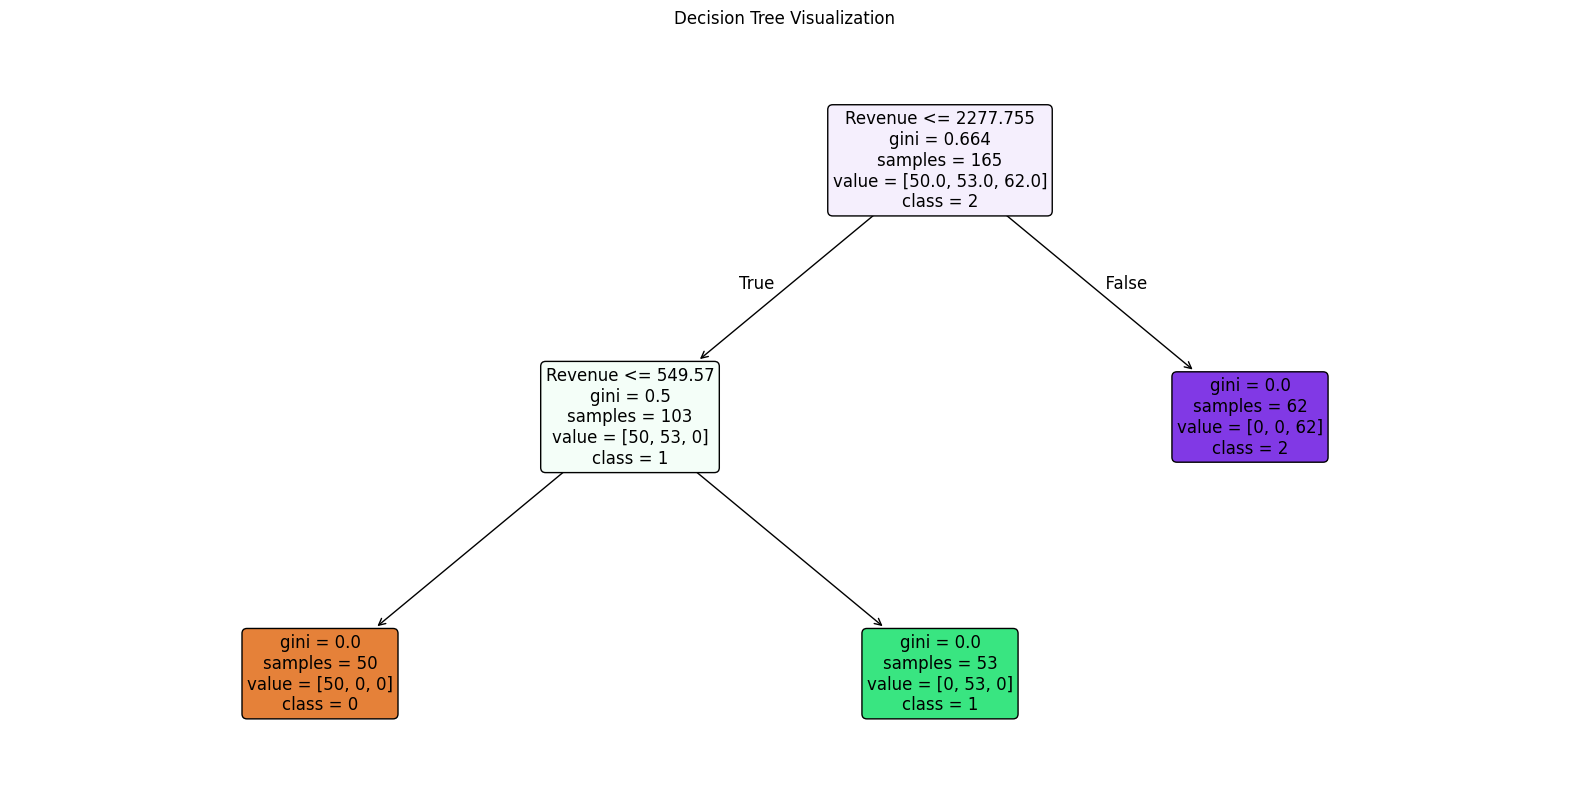

In [60]:


# -------------------- Step 1: Scale Features --------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------- Step 2: Train/Test Split --------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# -------------------- Step 3: Hyperparameter Tuning --------------------
param_grid = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

best_svc = grid.best_estimator_
print("Best SVC Parameters:", grid.best_params_)

# -------------------- Step 4: Predictions --------------------
svc_pred = best_svc.predict(X_test)

# -------------------- Step 5: Confusion Matrix --------------------
print("Confusion matrix SVC")
print(confusion_matrix(y_test, svc_pred))

# -------------------- Step 6: SVC Metrics --------------------
print("\n===== Scores SVC =====")
print("Accuracy:", accuracy_score(y_test, svc_pred))
print("Precision (macro):", precision_score(y_test, svc_pred, average='macro', zero_division=0))
print("Recall (macro):", recall_score(y_test, svc_pred, average='macro', zero_division=0))
print("F1-score (macro):", f1_score(y_test, svc_pred, average='macro', zero_division=0))

# -------------------- Step 7: Prediction Map --------------------
plt.figure(figsize=(6,4))
plt.plot(y_test, marker='x', linestyle='', label='True Labels')
plt.plot(dt_pred, marker='o', linestyle='', label='DT Predictions')
plt.title('Decision Tree Prediction Map')
plt.xlabel('Sample Index')
plt.ylabel('Revenue Category')
plt.legend()
plt.show()

# -------------------- Step 2: Confusion Matrix --------------------
print("Confusion matrix Decision Tree")
print(confusion_matrix(y_test, dt_pred))

# -------------------- Step 3: Metrics --------------------
print("\n===== Scores Decision Tree =====")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision (macro):", precision_score(y_test, dt_pred, average='macro', zero_division=0))
print("Recall (macro):", recall_score(y_test, dt_pred, average='macro', zero_division=0))
print("F1-score (macro):", f1_score(y_test, dt_pred, average='macro', zero_division=0))
print("\nClassification Report:\n", classification_report(y_test, dt_pred, zero_division=0))
# -------------------- Step 5: Visualize Tree --------------------
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=[rev_col, ebitda_col],
    class_names=[str(c) for c in sorted(df_clean['Revenue_cat'].unique())],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title('Decision Tree Visualization')
plt.show()



## Objective 5: Regression using Linear & RandomForest Regression with Line Maps


Step 1: Creating sample regression data

Step 2: Fitting Linear Regression

Step 3: Fitting Random Forest Regressor

Step 4: Plotting regression predictions


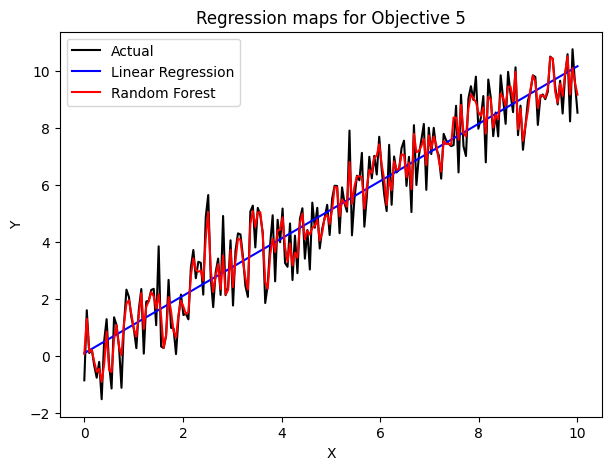


Step 5: Computing regression metrics

Linear Regression Metrics:
R2 Score: 0.8969566015254468
MSE: 0.9803818942432292
RMSE: 0.9901423605942881
MAE: 0.8186070425123191
Explained Variance Score: 0.8969566015254468

Random Forest Regression Metrics:
R2 Score: 0.9752144627487733
MSE: 0.23581609612957877
RMSE: 0.4856089951077706
MAE: 0.3648889619347869
Explained Variance Score: 0.975325733427548


In [51]:
# -------------------- Step 1: Create Sample Data --------------------


## Objective 6: Ensemble Learning using Voting & Bagging Classifier with Feature Maps





===== Voting Classifier Metrics =====
Accuracy: 0.9859154929577465
Precision (macro): 0.9871794871794872
Recall (macro): 0.9885057471264368
F1-score (macro): 0.9876160990712074

Confusion Matrix:
 [[28  1  0]
 [ 0 25  0]
 [ 0  0 17]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.96      1.00      0.98        25
           2       1.00      1.00      1.00        17

    accuracy                           0.99        71
   macro avg       0.99      0.99      0.99        71
weighted avg       0.99      0.99      0.99        71


===== Bagging Classifier Metrics =====
Accuracy: 0.9859154929577465
Precision (macro): 0.9871794871794872
Recall (macro): 0.9885057471264368
F1-score (macro): 0.9876160990712074

Confusion Matrix:
 [[28  1  0]
 [ 0 25  0]
 [ 0  0 17]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98

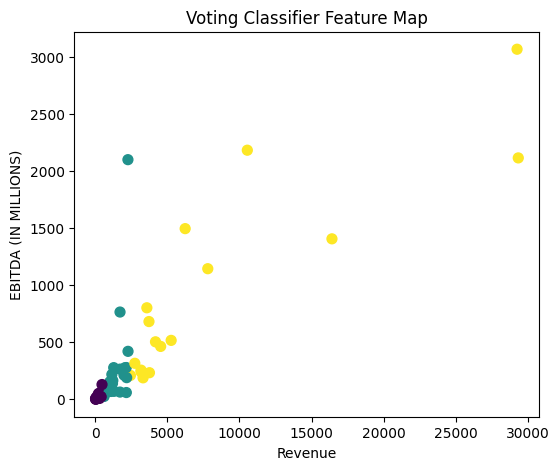

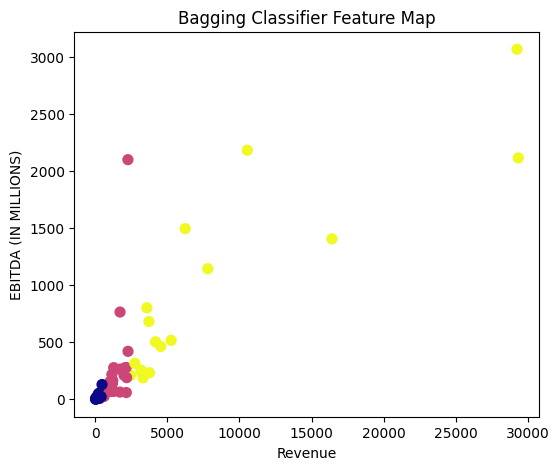

In [46]:
# -------------------- Classifiers --------------------
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf3 = SVC(probability=True)

voting = VotingClassifier(
    estimators=[('lr', clf1), ('dt', clf2), ('svc', clf3)],
    voting='soft'
)

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,
    random_state=42
)

# -------------------- Data --------------------
# Create categorical label from Revenue
df_clean['Revenue_cat'] = pd.qcut(df_clean['Revenue'], q=3, labels=[0, 1, 2])

# Features
X = df_clean[['Revenue', 'EBITDA (IN MILLIONS)']]
y = df_clean['Revenue_cat']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -------------------- Fit Models --------------------
voting.fit(X_train, y_train)
bagging.fit(X_train, y_train)

v_pred = voting.predict(X_test)
b_pred = bagging.predict(X_test)

# -------------------- Voting Classifier Metrics --------------------
print("\n===== Voting Classifier Metrics =====")
print("Accuracy:", accuracy_score(y_test, v_pred))
print("Precision (macro):", precision_score(y_test, v_pred, average='macro', zero_division=0))
print("Recall (macro):", recall_score(y_test, v_pred, average='macro', zero_division=0))
print("F1-score (macro):", f1_score(y_test, v_pred, average='macro', zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, v_pred))
print("\nClassification Report:\n", classification_report(y_test, v_pred, zero_division=0))

# -------------------- Bagging Classifier Metrics --------------------
print("\n===== Bagging Classifier Metrics =====")
print("Accuracy:", accuracy_score(y_test, b_pred))
print("Precision (macro):", precision_score(y_test, b_pred, average='macro', zero_division=0))
print("Recall (macro):", recall_score(y_test, b_pred, average='macro', zero_division=0))
print("F1-score (macro):", f1_score(y_test, b_pred, average='macro', zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, b_pred))
print("\nClassification Report:\n", classification_report(y_test, b_pred, zero_division=0))

# -------------------- Voting Classifier Feature Map --------------------
plt.figure(figsize=(6,5))
plt.scatter(X_test['Revenue'], X_test['EBITDA (IN MILLIONS)'], c=v_pred, cmap='viridis', s=50)
plt.title('Voting Classifier Feature Map')
plt.xlabel('Revenue')
plt.ylabel('EBITDA (IN MILLIONS)')
plt.show()

# -------------------- Bagging Classifier Feature Map --------------------
plt.figure(figsize=(6,5))
plt.scatter(X_test['Revenue'], X_test['EBITDA (IN MILLIONS)'], c=b_pred, cmap='plasma', s=50)
plt.title('Bagging Classifier Feature Map')
plt.xlabel('Revenue')
plt.ylabel('EBITDA (IN MILLIONS)')
plt.show()

## Objective 7: Neural Network Model with Loss Curve Maps


===== Confusion Matrix: MLP =====
[[28  1  0]
 [ 1 21  3]
 [ 0  2 15]]

===== MLP Metrics =====
Accuracy: 0.9014084507042254
Precision (macro): 0.8912835249042147
Recall (macro): 0.8959567275185937
F1-score (macro): 0.8932676518883415

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        29
           1       0.88      0.84      0.86        25
           2       0.83      0.88      0.86        17

    accuracy                           0.90        71
   macro avg       0.89      0.90      0.89        71
weighted avg       0.90      0.90      0.90        71

5-Fold Cross-Validation Accuracy: 0.7414893617021276


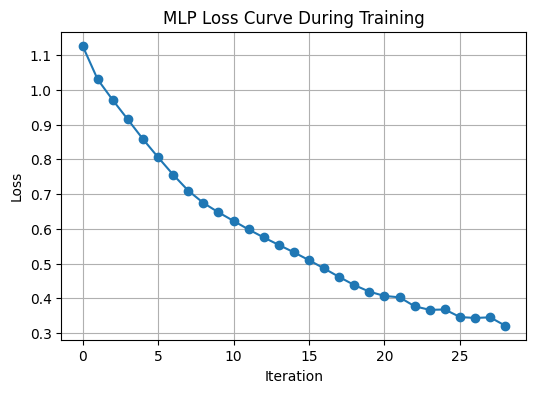

In [68]:
# -------------------- Features & Target --------------------
X = df_clean[['Revenue', 'EBITDA (IN MILLIONS)']].copy()
y = df_clean['Revenue_cat']

# -------------------- Feature Scaling --------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------- Train/Test Split --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# -------------------- MLP Classifier --------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50, 30),  # larger network
    max_iter=500,                       # allow convergence
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    early_stopping=True,
    random_state=42
)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

# -------------------- Confusion Matrix --------------------
cm_mlp = confusion_matrix(y_test, mlp_pred)
print("===== Confusion Matrix: MLP =====")
print(cm_mlp)

# -------------------- Classification Metrics --------------------
print("\n===== MLP Metrics =====")
print("Accuracy:", accuracy_score(y_test, mlp_pred))
print("Precision (macro):", precision_score(y_test, mlp_pred, average='macro', zero_division=0))
print("Recall (macro):", recall_score(y_test, mlp_pred, average='macro', zero_division=0))
print("F1-score (macro):", f1_score(y_test, mlp_pred, average='macro', zero_division=0))
print("\nClassification Report:\n", classification_report(y_test, mlp_pred, zero_division=0))

# -------------------- Cross-Validation --------------------
cv_scores = cross_val_score(mlp, X_scaled, y, cv=5, scoring='accuracy')
print("5-Fold Cross-Validation Accuracy:", cv_scores.mean())

# -------------------- Loss Curve --------------------
plt.figure(figsize=(6,4))
plt.plot(mlp.loss_curve_, marker='o')
plt.title('MLP Loss Curve During Training')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.show()
